# Topic 7 Example 8

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Course utilities (do not modify this cell)        
import sys
import os
base_path = os.path.expanduser("~/Documents/GitHub/Signals_and_Systems")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "courseutils"))

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()

import control_materials as cm
print("Control Material version:", cm.__version__)
cm.setup_environment()


Basic Material version: 16.002-0.1


Control Material version: 16.002-0.1


In [3]:
colors = bm.get_colors()
j = complex(0,1)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText
import sympy as sp

import control as ct
import control.matlab as cmat

from sympy import fourier_transform, cos,  re, cos
from sympy.abc import f 
from sympy import re 

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

In [4]:
from sympy import Symbol, Piecewise, lambdify, sinc, pi

t = Symbol('t')
y = Symbol('y')
z = Symbol('z')
p = Symbol('p')

def my_rect(p=1):
    return Piecewise((0, t <= -p/2), (1, t <= p/2), (0, True))

def my_tri(p=1, tc=0):
    return Piecewise(
        (0, t <= tc-p),
        (t - (tc-p), t <= tc),
        (tc + p - t, t <= tc+p),
        (0, True)
    )

lam_rect = lambdify((t, y), my_rect(y), modules=['numpy'])
lam_tri = lambdify((t, y, z), my_tri(y, z), modules=['numpy'])

sincu = lambda x, p: sinc(p*pi*x)

In [5]:
f7a = my_tri(1,-1) + my_tri(1,0) + my_tri(1,1)
lam_f7a = lambdify(t, f7a, modules=['numpy'])
Q7a = fourier_transform(f7a, t, f)
lam_Q7a = lambdify(f, re(Q7a), modules=['numpy'])

# see section 7.6
def Q7_analytic(f):
    return (1+2*np.cos(2*np.pi*f))*np.sinc(f)**2 ## numpy sinc doesn't require the pi, sympy's does

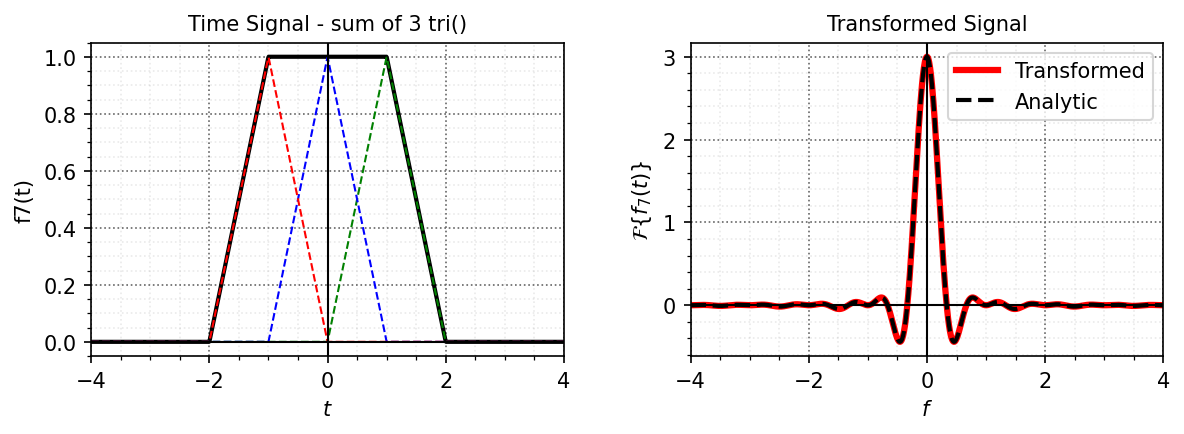

In [6]:
tt = np.linspace(-4,4,1000)
ff = np.linspace(-4,4,1000)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,3), dpi=150)
ax1.plot(tt, lam_f7a(tt), 'k-', lw=2)
ax1.plot(tt, lam_tri(tt-1,1,0), 'g--', lw=1)
ax1.plot(tt, lam_tri(tt,1,0), 'b--', lw=1)
ax1.plot(tt, lam_tri(tt+1,1,0), 'r--', lw=1)
ax1.set_title('Time Signal - sum of 3 tri()')
ax1.set_ylabel('f7(t)')
ax1.set_xlabel('$t$')
bm.nicegrid(ax1)

ax2.plot(ff, lam_Q7a(ff), 'r-', lw=3,label='Transformed')
ax2.plot(ff, Q7_analytic(ff), 'k--', lw=2,label='Analytic')
ax2.set_title('Transformed Signal')
ax2.set_ylabel('${\cal F}\{ f_7(t)\}$')
ax2.set_xlabel('$f$')
bm.nicegrid(ax2)
plt.legend()
plt.show()

## Example - Truncated Cosine - Multiplication/Convolution

In [7]:
p = 1
m = 10
SS6 = my_rect(p)*cos(2*pi*m*t)
lam_SS6 = lambdify(t, SS6, modules=['numpy'])
QSS6 = fourier_transform(SS6, t, f)
lam_QSS6 = lambdify(f, QSS6, modules=['numpy'])

def QSS6_analytic(f):
    return p/2*(np.sinc(p*f-p*m) + np.sinc(p*f+p*m)) ## numpy sinc doesn't require the pi, sympy's does

tlim = 20/m
tt = np.linspace(-tlim, tlim, 1000)
flim = 1/p+2*m
ff = np.linspace(-flim, flim, 1000)
ts = Symbol('t')

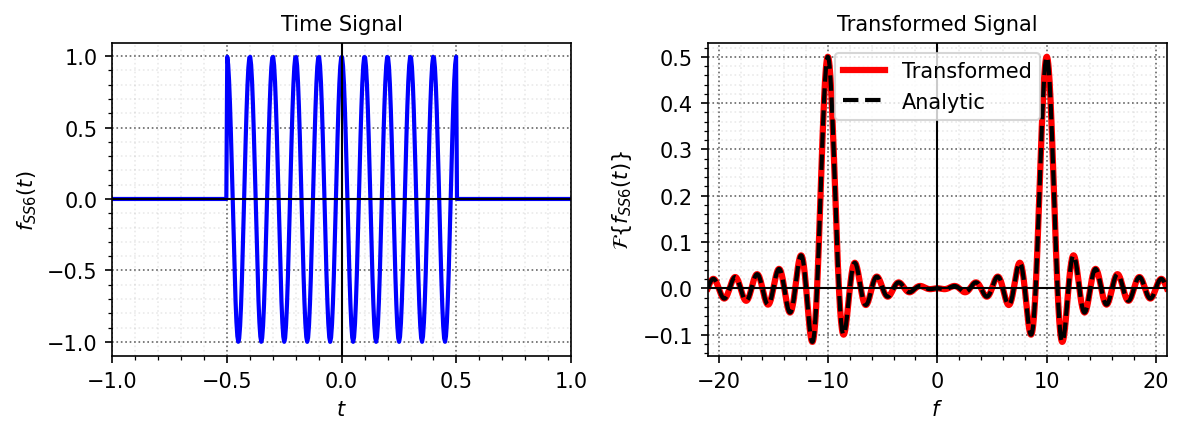

In [8]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,3), dpi=150)
ax1.plot(tt, lam_SS6(tt), 'b-', lw=2)
ax1.set_title('Time Signal')
ax1.set_ylabel('$f_{SS6}(t)$')
ax1.set_xlabel('$t$')
ax1.set_xlim(-1,1)
bm.nicegrid(ax1)

ax2.plot(ff, lam_QSS6(ff), 'r-', lw=3,label='Transformed')
ax2.plot(ff, QSS6_analytic(ff), 'k--', lw=2,label='Analytic')
ax2.set_title('Transformed Signal')
ax2.set_ylabel('${\cal F}\{ f_{SS6}(t)\}$')
ax2.set_xlabel('$f$')
bm.nicegrid(ax2)
plt.legend()
plt.show()